# ENTRENAMIENTO DE MODELOS

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn import metrics
import xgboost as xgb
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

In [93]:
df_pasta_train = pd.read_csv("data/train_limpio.csv", sep=",")
df_pasta_train.head()

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs,MonthlyIncome_sin_con,NumberOfDependents_vacio_si_no
0,9580,0.668999,58,2,0.449504,3425.0,9,1,1,1,1.0,0,0,0
1,39755,0.015922,71,0,6.000000,5400.0,5,0,0,0,0.0,0,1,0
2,118799,0.183062,52,1,0.035593,5000.0,9,0,0,0,0.0,0,0,0
3,16489,0.162301,77,0,0.227886,2000.0,8,0,0,0,0.0,0,0,0
4,149857,0.404199,30,0,0.026010,5843.0,4,0,0,0,0.0,0,0,0


In [3]:
df_pasta_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    105000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  105000 non-null  float64
 2   Age                                   105000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  105000 non-null  int64  
 4   DebtRatio                             105000 non-null  float64
 5   MonthlyIncome                         105000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       105000 non-null  int64  
 7   NumberOfTimes90DaysLate               105000 non-null  int64  
 8   NumberRealEstateLoansOrLines          105000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  105000 non-null  int64  
 10  NumberOfDependents                    105000 non-null  float64
 11  

In [4]:
df_pasta_train.corr()

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs,MonthlyIncome_sin_con,NumberOfDependents_vacio_si_no
ID,1.000000,0.000154,0.002974,0.002196,-0.003007,0.002380,0.002774,0.001033,-0.001972,0.001497,-0.000242,0.001857,-0.000757,0.000954
RevolvingUtilizationOfUnsecuredLines,0.000154,1.000000,-0.004256,-0.001181,0.003941,0.004230,-0.013877,-0.001193,0.007394,-0.001104,0.000685,-0.001685,0.003599,0.000342
Age,0.002974,-0.004256,1.000000,-0.062235,0.025206,0.023440,0.145692,-0.060004,0.029178,-0.056341,-0.213789,-0.114572,0.139712,0.086164
NumberOfTime30-59DaysPastDueNotWorse,0.002196,-0.001181,-0.062235,1.000000,-0.007335,-0.006633,-0.052518,0.982646,-0.028891,0.986302,-0.002165,0.124291,0.021066,0.020758
DebtRatio,-0.003007,0.003941,0.025206,-0.007335,1.000000,-0.018294,0.055192,-0.009186,0.130042,-0.008252,-0.050302,-0.008401,0.358667,0.069156
MonthlyIncome,0.002380,0.004230,0.023440,-0.006633,-0.018294,1.000000,0.079367,-0.008755,0.102765,-0.007592,0.061606,-0.016486,-0.035774,-0.011822
NumberOfOpenCreditLinesAndLoans,0.002774,-0.013877,0.145692,-0.052518,0.055192,0.079367,1.000000,-0.078131,0.435138,-0.069019,0.073705,-0.028543,-0.117413,-0.088929
NumberOfTimes90DaysLate,0.001033,-0.001193,-0.060004,0.982646,-0.009186,-0.008755,-0.078131,1.000000,-0.044308,0.992445,-0.009648,0.114855,0.028542,0.023828
NumberRealEstateLoansOrLines,-0.001972,0.007394,0.029178,-0.028891,0.130042,0.102765,0.435138,-0.044308,1.000000,-0.038554,0.131944,-0.006987,-0.064459,-0.061775
NumberOfTime60-89DaysPastDueNotWorse,0.001497,-0.001104,-0.056341,0.986302,-0.008252,-0.007592,-0.069019,0.992445,-0.038554,1.000000,-0.010476,0.100458,0.027812,0.024055


<Axes: >

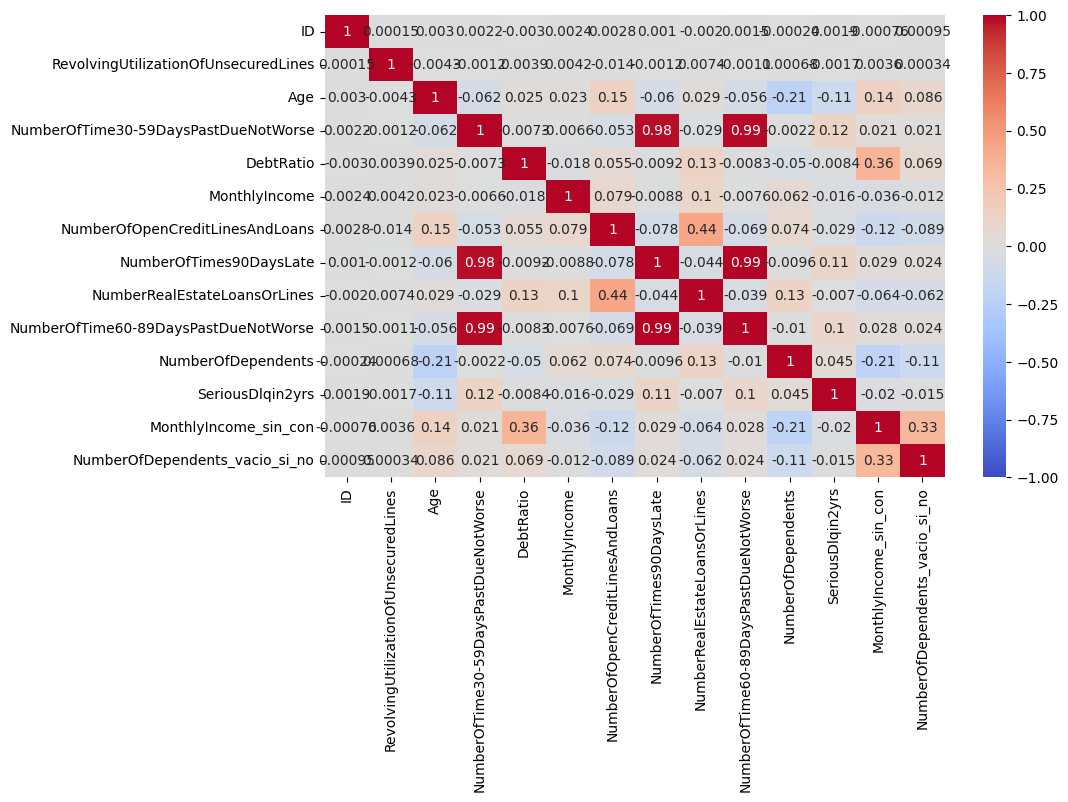

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_pasta_train.corr(), annot=True, vmin=-1, cmap="coolwarm")

In [94]:
X = df_pasta_train.drop(columns=["ID", "SeriousDlqin2yrs"], axis=1)
y = df_pasta_train["SeriousDlqin2yrs"]

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(84000, 12)
(84000,)
(21000, 12)
(21000,)


# Prueba modelos 1: todas las variables menos ID y sin normalizar

### Logistic Regression

In [53]:
lr_model = LogisticRegression(
    max_iter=1000,      
    class_weight='balanced', 
    random_state=11
)

lr_model.fit(X_train, y_train)

y_proba = lr_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_proba)
print("AUC: ", round(auc, 4))

AUC:  0.7948


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [54]:
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=11
)

lr_model.fit(X_train_scal, y_train)

y_proba = lr_model.predict_proba(X_test_scal)[:,1]

auc = roc_auc_score(y_test, y_proba)
print("AUC: ", round(auc, 4))

AUC:  0.7953


# Prueba modelos 2: todas las variables menos ID y sin normalizar

### RandomForest

In [55]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight='balanced', # correción del desbalanceo de clases
    random_state=11,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_test_proba = rf_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_test_proba)
print("AUC: ", round(auc, 4))

AUC:  0.8453


In [56]:
rf = RandomForestClassifier(
    random_state=11,
    class_weight='balanced',
    n_jobs=-1
)

parametros = {
    "n_estimators": [100, 300, 500],        
    "max_depth": [None, 10, 20],  
    # sqrt: Usa la raíz cuadrada del número total de features    
    # #log₂(número_de_features) - ejemplo: log₂(16) = 4      
    "max_features": ["sqrt", "log2"],       
    "max_leaf_nodes": [None, 20]           
}

grid = GridSearchCV(
    rf,
    param_grid=parametros,
    cv=3,                
    scoring="roc_auc", 
    verbose=3
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor ROC-AUC:", grid.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV 1/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=100;, score=0.828 total time=   3.6s
[CV 2/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=100;, score=0.827 total time=   3.6s
[CV 3/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=100;, score=0.834 total time=   3.5s
[CV 1/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=300;, score=0.835 total time=  10.1s
[CV 2/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=300;, score=0.832 total time=  10.0s
[CV 3/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=300;, score=0.842 total time=  10.1s
[CV 1/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=500;, score=0.837 total time=  16.6s
[CV 2/3] END max_depth=None, max_features=sqrt, max_leaf_nodes=None, n_estimators=500;, score=0.834 total

### XGBoost

In [96]:
xgb_model = xgboost.XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8, # Usa solo el 80% de las filas (muestras) para entrenar cada árbol
    colsample_bytree=0.8, # Usa solo el 80% de las columnas (features) para entrenar cada árbol
    min_child_weight=3, # Un nodo solo se divide si el "peso" mínimo de sus muestras es ≥ 3.
    random_state=11,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_pred)
print("AUC:", round(auc, 4))


AUC: 0.8695


In [89]:
xgb_model = xgb.XGBClassifier(
    random_state=11,
    eval_metric='auc',
    n_jobs=-1
)

param_grid = {
    'n_estimators': [400, 600],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [1, 3]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=3
)

grid_xgb.fit(X_train, y_train)

print("Mejores parámetros:", grid_xgb.best_params_)
print("Mejor ROC-AUC (CV):", grid_xgb.best_score_)

y_test_proba = grid_xgb.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_test_proba)
print("AUC sobre test:", round(auc_test, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV 1/3] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400, subsample=0.8;, score=0.858 total time=   1.6s
[CV 2/3] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400, subsample=0.8;, score=0.857 total time=   1.4s
[CV 3/3] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400, subsample=0.8;, score=0.863 total time=   1.6s
[CV 1/3] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=600, subsample=0.8;, score=0.858 total time=   2.1s
[CV 2/3] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=600, subsample=0.8;, score=0.858 total time=   2.0s
[CV 3/3] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=600, subsample=0.8;, score=0.865 total time=   2.1s
[CV 1/3] END colsampl

In [58]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=11,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.05, 0.1],

}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,                
    scoring='roc_auc',
    verbose=3
)

grid_xgb.fit(X_train, y_train)

print("Mejores parámetros:", grid_xgb.best_params_)
print("Mejor ROC-AUC (CV):", grid_xgb.best_score_)

y_test_proba = grid_xgb.predict_proba(X_test)[:,1]

auc_test = roc_auc_score(y_test, y_test_proba)
print("AUC sobre test:", round(auc_test, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV 1/5] END learning_rate=0.01, max_depth=4, n_estimators=200;, score=0.847 total time=   0.3s
[CV 2/5] END learning_rate=0.01, max_depth=4, n_estimators=200;, score=0.858 total time=   0.2s
[CV 3/5] END learning_rate=0.01, max_depth=4, n_estimators=200;, score=0.856 total time=   0.2s
[CV 4/5] END learning_rate=0.01, max_depth=4, n_estimators=200;, score=0.848 total time=   0.2s
[CV 5/5] END learning_rate=0.01, max_depth=4, n_estimators=200;, score=0.865 total time=   0.2s
[CV 1/5] END learning_rate=0.01, max_depth=4, n_estimators=400;, score=0.849 total time=   0.5s
[CV 2/5] END learning_rate=0.01, max_depth=4, n_estimators=400;, score=0.862 total time=   0.5s
[CV 3/5] END learning_rate=0.01, max_depth=4, n_estimators=400;, score=0.859 total time=   0.5s
[CV 4/5] END learning_rate=0.01, max_depth=4, n_estimators=400;, score=0.853 total time=   0.5s
[CV 5/5] END learning_rate=0.01, max_depth=4, n_estimators=400;, score=0.87

In [ ]:
df_test = pd.read_csv("data/test_limpio.csv")

test_ids = df_test["ID"]

X_test = df_test.drop(columns=["ID"])

y_test_proba = xgb_model.predict_proba(X_test)[:,1]

submission = pd.DataFrame({
    "ID": test_ids,
    "SeriousDlqin2yrs": y_test_proba
})

submission.to_csv("submission_xgb.csv", index=False)